<a href="https://colab.research.google.com/github/Jamee95/ubran_sound_classification/blob/code/AST_model_Urban_Sound_Classification(UrbanSound8K)_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN model**

In [ ]:
X_np = X.to_numpy()
X_cnn = X_np.reshape(X_np.shape[0], X_np.shape[1], 1)

print("Original X shape (DataFrame):", X.shape)
print("Original X shape (NumPy array):", X_np.shape)
print("Reshaped X for CNN (X_cnn) shape:", X_cnn.shape)

Original X shape (DataFrame): (8732, 40)
Original X shape (NumPy array): (8732, 40)
Reshaped X for CNN (X_cnn) shape: (8732, 40, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Get the input shape from X_cnn and the number of classes
input_shape = (X_cnn.shape[1], X_cnn.shape[2]) # (40, 1)
num_classes = len(le.classes_)

# Define the CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("CNN Model Summary:")
cnn_model.summary()

CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,450 (615.04 KB)

 Trainable params: 157,450 (615.04 KB)

 Non-trainable params: 0 (0.00 B)

Train samples for CNN: 6985
Test samples for CNN: 1747

 Training CNN Neural Network...
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Classification Report for CNN Neural Network:

                  precision    recall  f1-score   support

 air_conditioner       0.96      0.97      0.96       200
        car_horn       0.94      0.90      0.92        86
children_playing       0.85      0.88      0.86       200
        dog_bark       0.90      0.88      0.89       200
        drilling       0.91      0.92      0.91       200
   engine_idling       0.95      0.98      0.97       200
        gun_shot       0.94      0.77      0.85        75
      jackhammer       0.95      0.93      0.94       200
           siren       0.93      0.96      0.94       186
    street_music       0.85      0.85      0.85       200

        accuracy                           0.91      1747
       macro avg       0.92      0.90      0.91      1747
    weighted avg       0.91      0.91      0.91      1747

 Accuracy

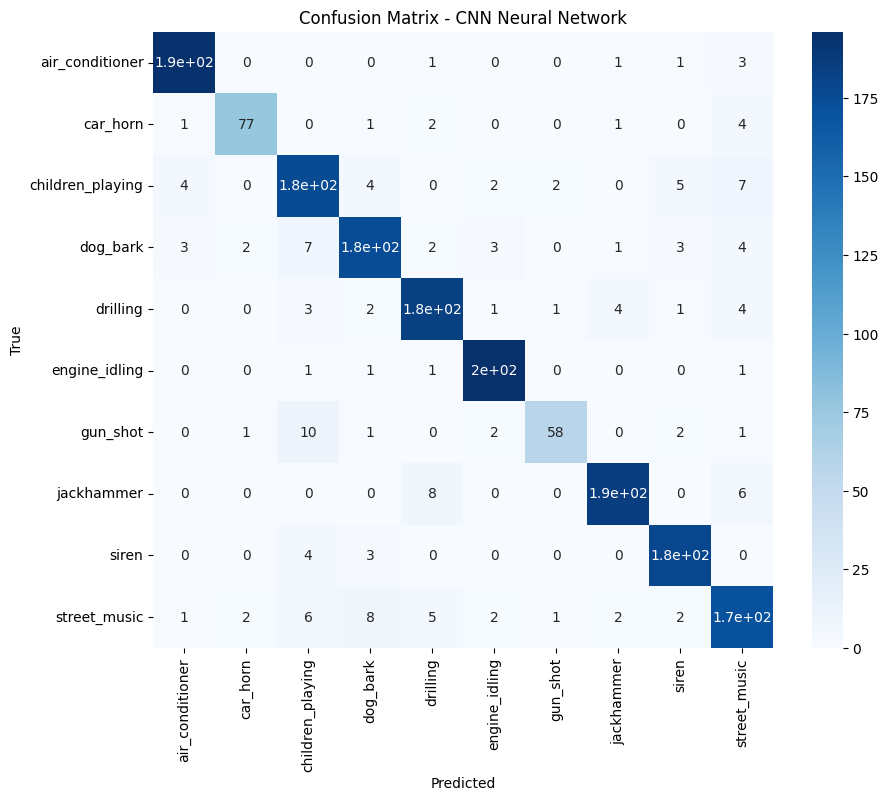

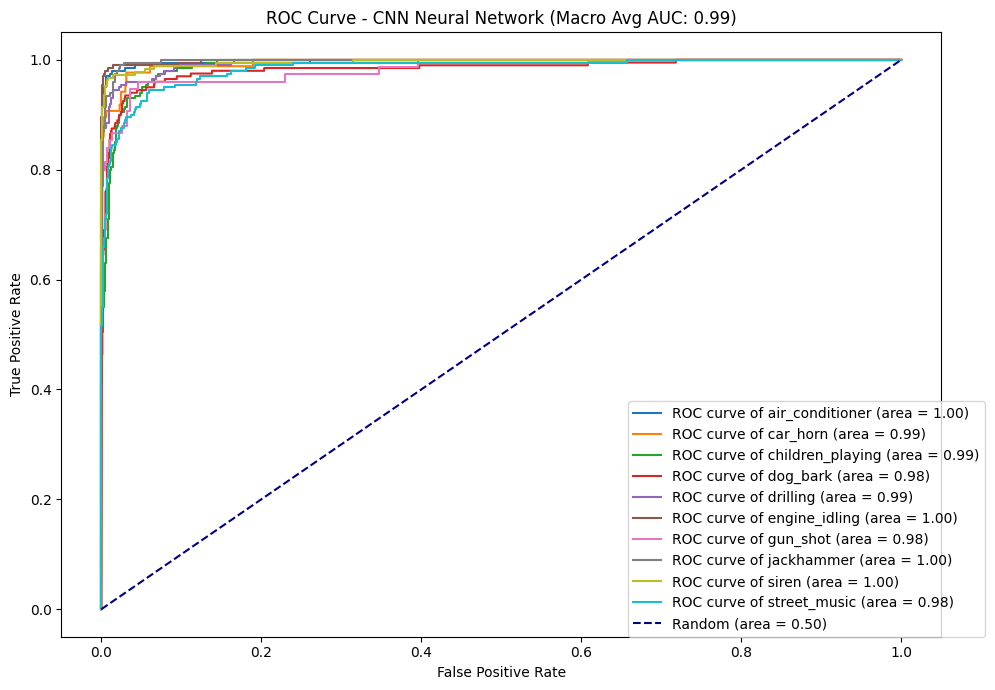

In [ ]:
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np
from sklearn.model_selection import train_test_split

# Re-split data specifically for CNN, ensuring consistency with previous split parameters
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train samples for CNN:", len(X_train_cnn))
print("Test samples for CNN:", len(X_test_cnn))

def evaluate_cnn_model(model, X_train, X_test, y_train, y_test, model_name, epochs=100, batch_size=32):
    print(f"\n Training {model_name}...")
    start = time.time()
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
    train_time = time.time() - start

    start_pred = time.time()
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    pred_time = time.time() - start_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_)
    print(f"\n Classification Report for {model_name}:\n")
    print(report)
    print(f" Accuracy: {acc:.4f}")
    print(f" Training Time: {train_time:.2f}s | Prediction Time: {pred_time:.2f}s")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curve (one-vs-rest)
    y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
    try:
        roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average='macro')

        plt.figure(figsize=(10, 7))
        for i, class_name in enumerate(le.classes_):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f'ROC curve of {class_name} (area = {auc(fpr, tpr):.2f})')

        plt.plot([0, 1], [0, 1], linestyle='--', color='navy', label='Random (area = 0.50)')
        plt.title(f"ROC Curve - {model_name} (Macro Avg AUC: {roc_auc:.2f})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right", bbox_to_anchor=(1.05, 0.0), borderaxespad=0.)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("ROC computation skipped:", e)

    return {"model": model_name, "accuracy": acc, "train_time": train_time, "pred_time": pred_time}

# Evaluate the CNN model
cnn_results = evaluate_cnn_model(cnn_model, X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn, "CNN Neural Network")

**Reasoning**:
The CNN model has been trained and evaluated. Now, I need to update the comparison table to include the CNN's performance metrics alongside the previously evaluated models (Random Forest, SVM, MLP) and then visualize the updated comparison.



,model,accuracy,train_time,pred_time
0,CNN Neural Network,0.913566,190.358674,0.371390
1,Random Forest,0.904408,14.285152,0.091174
2,MLP Neural Network,0.870063,16.520765,0.011264
3,Support Vector Machine,0.692044,13.038331,0.835472


/tmp/ipython-input-2479896408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y='accuracy', data=results_df_updated, palette='viridis')


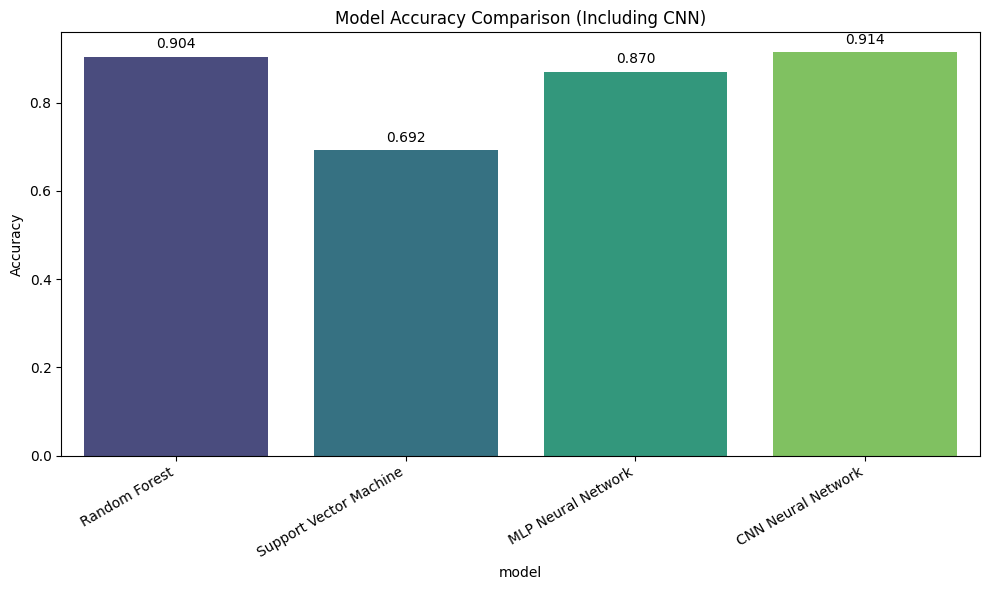

In [ ]:
results_df_updated = pd.DataFrame([rf_results, svm_results, mlp_results, cnn_results])
display(results_df_updated.sort_values(by='accuracy', ascending=False).reset_index(drop=True))

plt.figure(figsize=(10,6))
ax = sns.barplot(x='model', y='accuracy', data=results_df_updated, palette='viridis')
plt.title("Model Accuracy Comparison (Including CNN)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha='right')

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

,model,accuracy,train_time,pred_time
0,CNN Neural Network,0.913566,190.358674,0.371390
1,Random Forest,0.904408,14.285152,0.091174
2,MLP Neural Network,0.870063,16.520765,0.011264
3,Support Vector Machine,0.692044,13.038331,0.835472


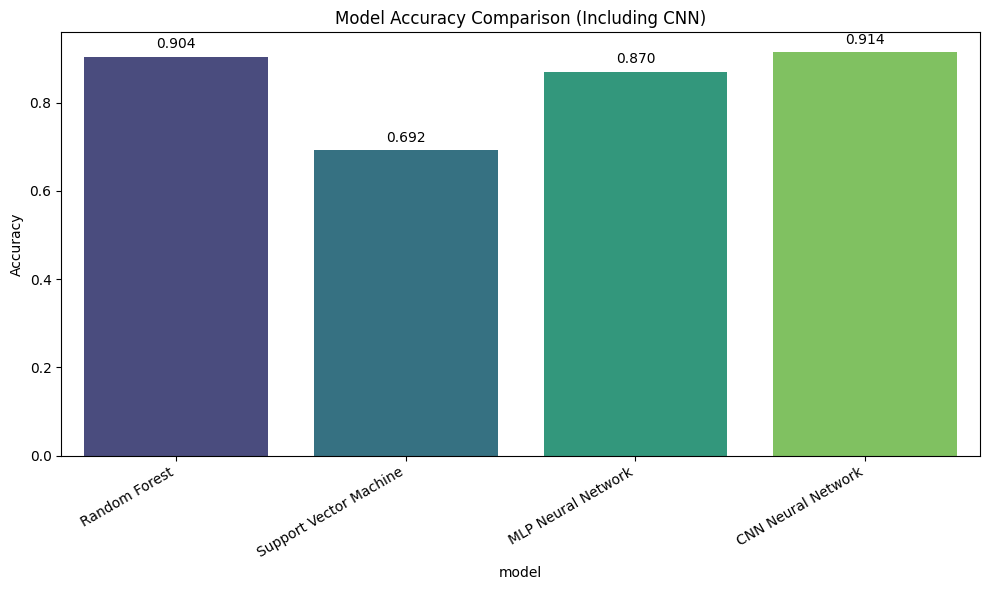

In [ ]:
results_df_updated = pd.DataFrame([rf_results, svm_results, mlp_results, cnn_results])
display(results_df_updated.sort_values(by='accuracy', ascending=False).reset_index(drop=True))

plt.figure(figsize=(10,6))
ax = sns.barplot(x='model', y='accuracy', hue='model', data=results_df_updated, palette='viridis', legend=False)
plt.title("Model Accuracy Comparison (Including CNN)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha='right')

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# **Extract Mel Spectrogram Features for AST**



In [ ]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
audio_root = "/content/UrbanSound8K/audio"
# 1. Define constants
target_sr = 22050
n_fft = 2048
hop_length = 512
n_mels = 128
max_pad_len = 250  # This represents the number of time frames

print(f"Defined constants: target_sr={target_sr}, n_fft={n_fft}, hop_length={hop_length}, n_mels={n_mels}, max_pad_len={max_pad_len}")

# 2. Initialize empty lists
ast_features = []
ast_labels = []

# Access audio_root and esc from previous steps
# audio_root = "/content/UrbanSound8K/audio" # Already defined earlier
# esc = pd.read_csv(...) # Already loaded earlier

# 3. Iterate through each row of the esc DataFrame
print("\nExtracting Mel Spectrogram features...")
for i in tqdm(range(len(esc)), desc="Processing audio files"):
    row = esc.iloc[i]
    fold = row['fold']
    file_name = row['slice_file_name']
    label = row['class'] # Assuming 'class' is the correct label column

    # a. Construct the full file path
    file_path = os.path.join(audio_root, f"fold{fold}", file_name)

    if not os.path.exists(file_path):
        # print(f"Warning: File not found {file_path}. Skipping.")
        continue

    try:
        # b. Load the audio file, resampling to target_sr
        y, sr = librosa.load(file_path, sr=target_sr, res_type='kaiser_fast')

        # c. Compute the Mel Spectrogram
        melspec = librosa.feature.melspectrogram(y=y, sr=target_sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

        # d. Convert to log scale
        melspec_db = librosa.power_to_db(melspec, ref=np.max)

        # e. Standardize dimensions (pad/trim)
        if melspec_db.shape[1] < max_pad_len:
            # Pad with zeros if shorter
            pad_width = max_pad_len - melspec_db.shape[1]
            padded_melspec = np.pad(melspec_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            # Trim if longer
            padded_melspec = melspec_db[:, :max_pad_len]

        # f. Append to lists
        ast_features.append(padded_melspec)
        ast_labels.append(label)

    except Exception as e:
        print(f"Error processing {file_name}: {e}. Skipping.")

# 5. Convert lists to NumPy array and Pandas Series
ast_features_array = np.array(ast_features)
ast_labels_series = pd.Series(ast_labels)

# 6. Print shape and display head
print("\nFeature extraction complete.")
print(f"Shape of ast_features_array: {ast_features_array.shape}")
print(f"Number of extracted labels: {len(ast_labels_series)}")
print("First 5 extracted labels:")
display(ast_labels_series.head())

Defined constants: target_sr=22050, n_fft=2048, hop_length=512, n_mels=128, max_pad_len=250

Extracting Mel Spectrogram features...


Processing audio files:  41%|████      | 3554/8732 [05:10<06:28, 13.33it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
Processing audio files:  95%|█████████▌| 8326/8732 [11:25<00:18, 22.12it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
Processing audio files: 100%|██████████| 8732/8732 [11:55<00:00, 12.20it/s]



Feature extraction complete.
Shape of ast_features_array: (8732, 128, 250)
Number of extracted labels: 8732
First 5 extracted labels:


,0
0,dog_bark
1,children_playing
2,children_playing
3,children_playing
4,children_playing


In [ ]:
pip install transformers accelerate evaluate scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import ASTConfig, ASTForAudioClassification, TrainingArguments, Trainer

# 1. Prepare Labels
label_encoder = LabelEncoder()
# Fit on the original pandas series labels
y_encoded = label_encoder.fit_transform(ast_labels_series)
num_labels = len(label_encoder.classes_)

print(f"Classes found: {label_encoder.classes_}")

# 2. Split Data (80% Train, 20% Test)
# We use 'stratify' to ensure all classes are represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    ast_features_array,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# 3. Define Custom Dataset Class
class UrbanSoundASTDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        # Standard AST input length is 1024. Your data is 250.
        # We must pad it to 1024 to use pre-trained weights.
        self.target_length = 1024

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Get feature: Current shape (128, 250) -> (Freq, Time)
        feature = self.features[idx]
        label = self.labels[idx]

        # Convert to Tensor
        feature_tensor = torch.tensor(feature, dtype=torch.float32)

        # Transpose to (Time, Freq) -> Shape becomes (250, 128)
        # AST expects (Time, Freq)
        feature_tensor = feature_tensor.transpose(0, 1)

        # Normalize (Standardization is crucial for Transformers)
        mean = feature_tensor.mean()
        std = feature_tensor.std()
        if std != 0:
            feature_tensor = (feature_tensor - mean) / std

        # Pad to target_length (1024)
        current_len = feature_tensor.shape[0]
        pad_len = self.target_length - current_len

        if pad_len > 0:
            # Pad the Time dimension (dim 0), keep Freq (dim 1) as is
            # padding format: (left, right, top, bottom) for last 2 dims if 4D,
            # but for 2D tensors, torch.nn.functional.pad works differently depending on input.
            # Easiest way for (Time, Freq) is to create a zero tensor and place data in it.
            padded_feature = torch.zeros((self.target_length, 128))
            padded_feature[:current_len, :] = feature_tensor
            feature_tensor = padded_feature
        else:
            # If your data were longer than 1024, we would crop it
            feature_tensor = feature_tensor[:self.target_length, :]

        return {
            "input_values": feature_tensor,
            "labels": torch.tensor(label, dtype=torch.long)
        }

# Create Dataset Objects
train_dataset = UrbanSoundASTDataset(X_train, y_train)
test_dataset = UrbanSoundASTDataset(X_test, y_test)

print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")

Classes found: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']
Train Dataset Size: 6985
Test Dataset Size: 1747


In [ ]:
from transformers import ASTForAudioClassification

# 1. Define the specific pre-trained model to download
model_checkpoint = "MIT/ast-finetuned-audioset-10-10-0.4593"

# 2. Load the model
# We use 'ignore_mismatched_sizes=True' because we are replacing the
# original 527-class layer with your 10-class layer.
model = ASTForAudioClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

# 3. Map the internal IDs to your actual class names (e.g., 0 -> "dog_bark")
# This makes future predictions easier to read.
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}
model.config.id2label = id2label
model.config.label2id = label2id

print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!


In [ ]:
# 4. Define Metrics Function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 5. Load Pre-trained AST Model
# We use 'ignore_mismatched_sizes' because the original model has 527 classes (AudioSet),
# and we are changing it to 10 classes (UrbanSound8K).
model_checkpoint = "MIT/ast-finetuned-audioset-10-10-0.4593"

model = ASTForAudioClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)

# Map label IDs to names for better inference later
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}
model.config.id2label = id2label
model.config.label2id = label2id

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

# 6. Define Training Arguments (Updated)
training_args = TrainingArguments(
    output_dir="./ast-urbansound-results",
    eval_strategy="epoch",            # CHANGED: evaluation_strategy -> eval_strategy
    save_strategy="epoch",            # Save model every epoch
    learning_rate=3e-5,               # AST needs a low learning rate
    per_device_train_batch_size=8,    # Reduce to 4 if you run out of GPU memory
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    save_total_limit=2,               # Only keep the last 2 checkpoints
    dataloader_num_workers=2,         # Parallel data loading
    remove_unused_columns=False,       # Important for custom datasets using 'input_values'
    report_to="none"
)

# 7. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 8. Train the model
print("Starting Training...")
trainer.train()

# 9. Final Evaluation
print("\nFinal Evaluation on Test Set:")
metrics = trainer.evaluate()
print(metrics)

Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.222300,0.241870,0.941042,0.941157,0.944636,0.941042
2,0.049400,0.149129,0.967373,0.967392,0.967622,0.967373
3,0.045500,0.118365,0.971380,0.971385,0.971642,0.971380
4,0.031600,0.115813,0.978248,0.978281,0.978557,0.978248


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.222300,0.241870,0.941042,0.941157,0.944636,0.941042
2,0.049400,0.149129,0.967373,0.967392,0.967622,0.967373
3,0.045500,0.118365,0.971380,0.971385,0.971642,0.971380
4,0.031600,0.115813,0.978248,0.978281,0.978557,0.978248
5,0.000000,0.105822,0.979966,0.979952,0.980110,0.979966



Final Evaluation on Test Set:


{'eval_loss': 0.10582181066274643, 'eval_accuracy': 0.979965655409273, 'eval_f1': 0.9799523534717477, 'eval_precision': 0.980109838959378, 'eval_recall': 0.979965655409273, 'eval_runtime': 138.1337, 'eval_samples_per_second': 12.647, 'eval_steps_per_second': 1.585, 'epoch': 5.0}


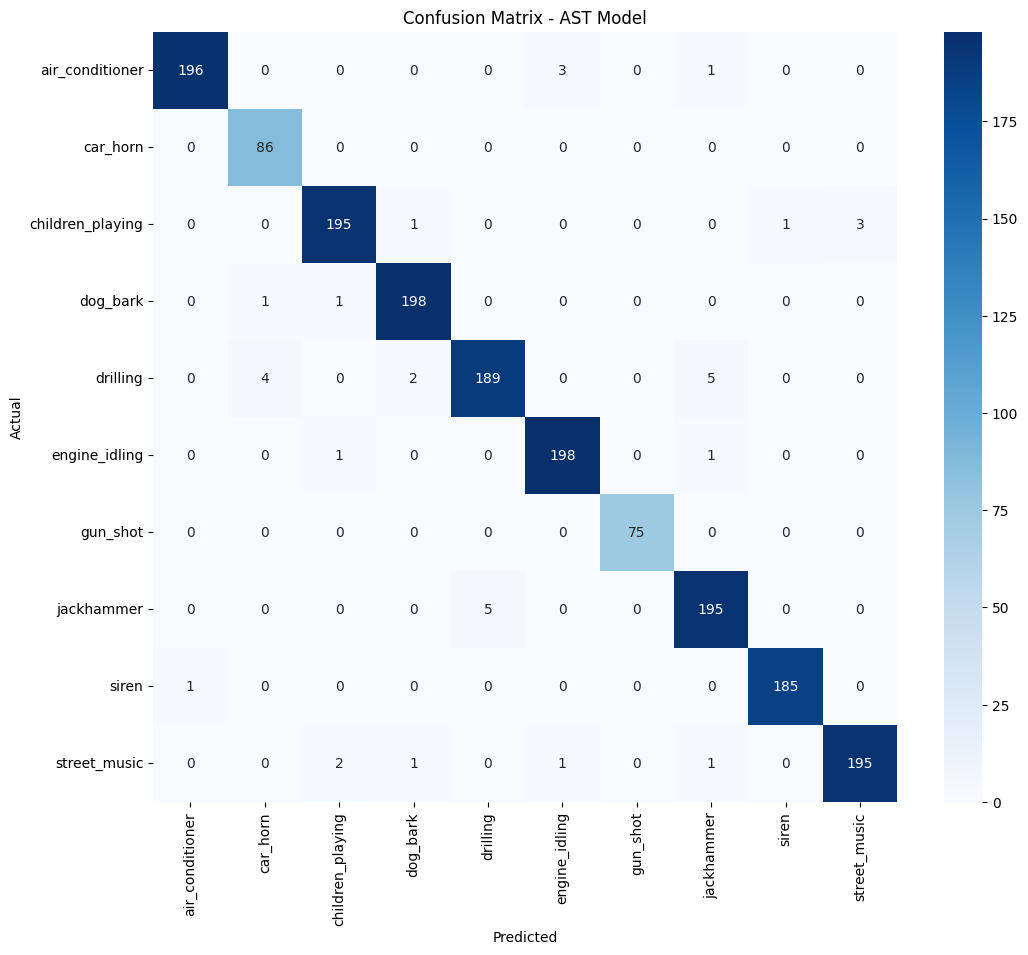

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions on the test set
predictions = trainer.predict(test_dataset)
y_preds = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

# Create Confusion Matrix
cm = confusion_matrix(y_true, y_preds)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AST Model')
plt.show()